# Registering MSI to WSI in code

This notebook registers a mass spectrometry image to its corresponding whole-slide image, inspects the returned transform, and uses it to render an overlay.

Registration uses the optional DreaMS embedding model. Install both extras with `pip install "imzdesk[examples,embeddings]"`. The model weights are downloaded from Hugging Face the first time they are needed. Embedding a full acquisition can take several minutes, particularly without a GPU.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import imzdesk.registration as R
import imzdesk.transforms as T
from imzdesk.core import PairedImage, Transform
from imzdesk.io import MSI, WSI

## Load a paired sample

The bundled files are used below. The path setup works from either the repository root or the `examples` directory. Replace `SAMPLE_DIR` to register another pair.

In [2]:
working_dir = Path.cwd()
if (working_dir / 'examples' / 'data').is_dir():
    examples_dir = working_dir / 'examples'
elif (working_dir / 'data').is_dir():
    examples_dir = working_dir
else:
    raise FileNotFoundError('Start Jupyter in the repository root or examples directory.')

SAMPLE_DIR = examples_dir / 'data' / 'MTBLS289' / 'A52 5cm S4'
WSI_PATH = SAMPLE_DIR / 'NICOLE A52 5CM 20.06.13 (4) - 2014-05-27 16.33.21.ndpi'
MSI_PATH = SAMPLE_DIR / 'A52 5cm S4-profile.imzML'

wsi = WSI(WSI_PATH)
msi = MSI(MSI_PATH, cache_portable=False)
print('WSI:', wsi.filepath.name)
print('MSI:', msi.filepath.name)

WSI: NICOLE A52 5CM 20.06.13 (4) - 2014-05-27 16.33.21.ndpi
MSI: A52 5cm S4-profile.imzML


## Estimate the registration

`register` builds tissue surrogates for both modalities, aligns their centroids, searches rotation, and refines the rigid transform using contour distance. By default it rasterizes the WSI at the axis-wise MSI resolution; setting `TARGET_MPP` explicitly makes that convention visible and gives us the resolution needed for the overlay later.

The returned `Transform` maps **MSI pixel coordinates into WSI pixel coordinates** at the registration raster resolution.

In [3]:
TARGET_MPP = (msi.metadata.mpp.x, msi.metadata.mpp.y)
registration = R.register(wsi, msi, target_mpp=TARGET_MPP)

print(type(registration).__name__)
print(registration.matrix)

Transform
[[-8.72653550e-03 -9.99961923e-01  2.21182057e+02]
 [ 9.99961923e-01 -8.72653550e-03  5.36231559e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]


## Use the returned transform

A `Transform` holds a homogeneous `3 x 3` matrix. `apply` maps `(x, y)` point arrays in the forward direction, `inverse()` reverses the mapping, and `@` composes transforms. Here the MSI acquisition corners are mapped into the WSI registration grid.

In [4]:
msi_corners = np.array([
    [0, 0],
    [msi.metadata.width, 0],
    [msi.metadata.width, msi.metadata.height],
    [0, msi.metadata.height],
])
wsi_corners = registration.apply(msi_corners)

print('MSI corners:\n', msi_corners)
print('Mapped WSI corners:\n', np.round(wsi_corners, 2))
print('Round trip:\n', np.round(registration.inverse().apply(wsi_corners), 2))

MSI corners:
 [[ 0  0]
 [51  0]
 [51 82]
 [ 0 82]]
Mapped WSI corners:
 [[221.18   5.36]
 [220.74  56.36]
 [138.74  55.64]
 [139.19   4.65]]
Round trip:
 [[ 0.  0.]
 [51.  0.]
 [51. 82.]
 [ 0. 82.]]


## Prepare images for an overlay

The WSI is rasterized at the same MPP passed to `register`. `crop=False` requests the full-slide coordinate frame; this remains correct when WSI crop metadata was used during registration because `register` includes that crop offset in its result.

For visualization, the MSI spectra are log-transformed, binned, and summed into one scalar intensity image. The geometric registration applies to the MSI pixel grid regardless of which scalar or multichannel MSI representation is displayed.

In [5]:
wsi_view = T.ToImage(target_mpp=TARGET_MPP, crop=False)(wsi)
msi_view = T.Compose([
    T.ToRImage(),
    T.Normalize('log1p'),
    T.Bin(minimum_channel=50.0, maximum_channel=1000.0, bin_width=2.0),
    T.TIC(),
    T.ToImage(),
])(msi)
registered_msi = R.warp(
    msi_view,
    registration,
    output_shape=wsi_view.shape[:2],
)

print('WSI raster:', wsi_view.shape)
print('MSI raster:', msi_view.shape)
print('registered MSI raster:', registered_msi.shape)

WSI raster: (62, 227, 3)
MSI raster: (83, 52)
registered MSI raster: (62, 227)


## Display the registration

`warp` resamples the moving MSI image into the fixed WSI grid. `Threshold` separates MSI tissue signal from low acquisition background, and the overlay uses the remaining intensity as both color and per-pixel opacity.

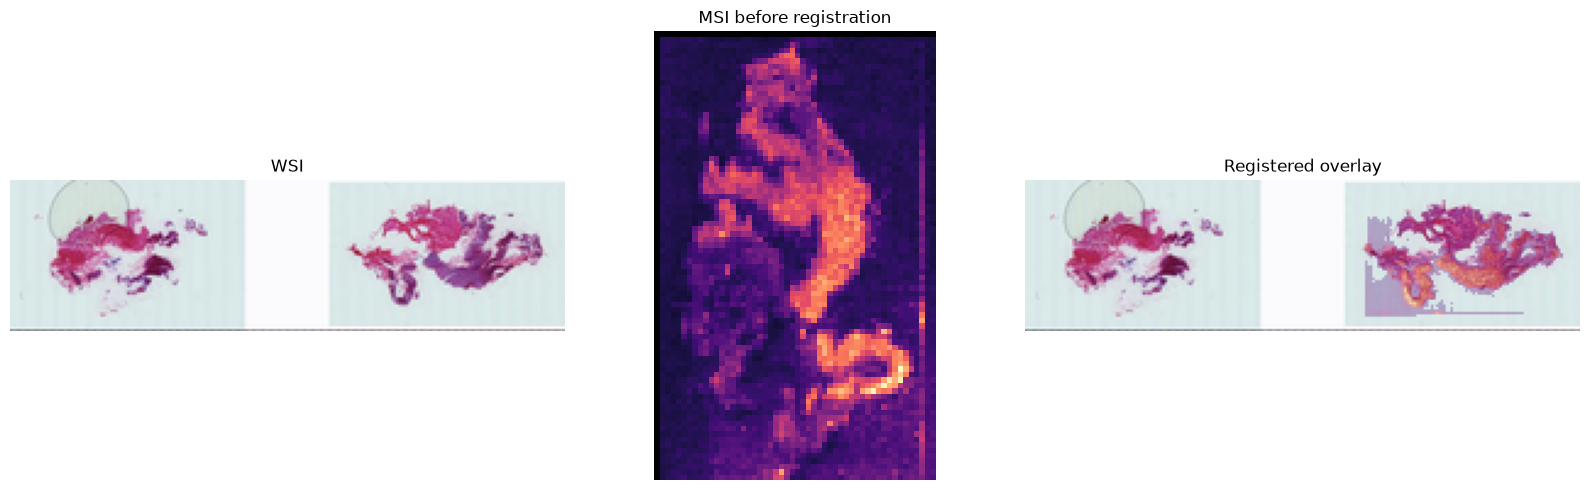

In [6]:
def scale01(values):
    values = np.asarray(values, dtype=np.float32)
    finite = values[np.isfinite(values)]
    if finite.size == 0 or finite.max() <= finite.min():
        return np.zeros_like(values)
    return np.clip((values - finite.min()) / (finite.max() - finite.min()), 0, 1)

registered_intensity = scale01(registered_msi)
overlay_mask = T.Threshold()(registered_intensity)
alpha = np.where(overlay_mask, 0.65 * registered_intensity + 0.15, 0)

figure, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(wsi_view)
axes[0].set_title('WSI')
axes[1].imshow(msi_view, cmap='magma')
axes[1].set_title('MSI before registration')
axes[2].imshow(wsi_view)
axes[2].imshow(registered_intensity, cmap='magma', alpha=alpha)
axes[2].set_title('Registered overlay')
for axis in axes:
    axis.axis('off')
plt.tight_layout()

## Carry the registration with the pair

`PairedImage` keeps the WSI, MSI, and transform together. Joint spatial transforms such as `RandomCrop` use this registration to select the same physical region from both modalities.

In [7]:
pair = PairedImage(wsi=wsi, msi=msi, registration=registration)
aligned_crop = T.RandomCrop((32, 32), mpp=TARGET_MPP, seed=0)(pair)

print(type(aligned_crop.wsi.data).__name__, aligned_crop.wsi.geometry.width, aligned_crop.wsi.geometry.height)
print(type(aligned_crop.msi.data).__name__, aligned_crop.msi.geometry.width, aligned_crop.msi.geometry.height)
print('crop registration:\n', aligned_crop.registration.matrix)

ndarray 32 32
RImage 32 32
crop registration:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


## Optional: persist the transform

The dataset loader discovers registrations from the sidecar path below. Saving is intentionally commented out so the notebook does not create or replace a registration sidecar. Use `allow_pickle=False` for both saving and loading.

In [8]:
registration_path = msi.derived_path(f'.{wsi.filepath.name}.transform.npy')
print(registration_path)

# registration_path.parent.mkdir(parents=True, exist_ok=True)
# np.save(registration_path, registration.matrix, allow_pickle=False)
# restored = Transform(np.load(registration_path, allow_pickle=False))

/home/aryan/Projects/imzDesk/examples/data/MTBLS289/A52 5cm S4/.imzDesk/A52 5cm S4-profile.NICOLE A52 5CM 20.06.13 (4) - 2014-05-27 16.33.21.ndpi.transform.npy
